In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def readRaw(rawfile: str, variables: list[str]) -> dict[str,list[float]]:
    out_dict = {}
    aux_dict = {}
    head = None

    with open(rawfile, 'r') as f:
        for line in f:
            linea = line.strip()
            #Flag para identificar la cabecera con las variables
            if(linea == 'Variables:'):
                head = True
            elif(linea == 'Values:'):
                head = False
            
            #Procesamiento de la cabecera y los datos
            if(head == True and linea != 'Variables:'):
                lin_split = linea.split()
                if lin_split[1] in variables:
                    aux_dict[int(lin_split[0])] = lin_split[1]
                    out_dict[lin_split[1]] = []

            elif(head == False and linea != 'Values:'):
                if(len(linea.split()) > 1):  #Nuevo instante de simulacion
                    offset = 0
                if offset in aux_dict:
                    if (offset != 0):
                        label = aux_dict[offset]
                        out_dict[label].append(float(linea))
                    else:
                        label = aux_dict[offset]
                        out_dict[label].append(float(linea.split()[1]))
                offset = offset + 1
    
    return out_dict


In [3]:
variables = ['time', 'v(vo_st7)','v(vo_st6)','v(vo_st5)', 'v(vo_st4)', 'v(vo_st3)', 'v(vo_st2)', 'v(vo_st1)']
resultados1V2 = readRaw('V2out1.raw',variables)
resultados2V2 = readRaw('V2out2.raw',variables)
resultados3V2 = readRaw('V2out3.raw',variables)
resultados4V2 = readRaw('V2out4.raw',variables)
resultados5V2 = readRaw('V2out5.raw',variables)
resultados6V2 = readRaw('V2out6.raw',variables)
resultados7V2 = readRaw('V2out7.raw',variables)
vector_tiempoV2 = resultados1V2['time']

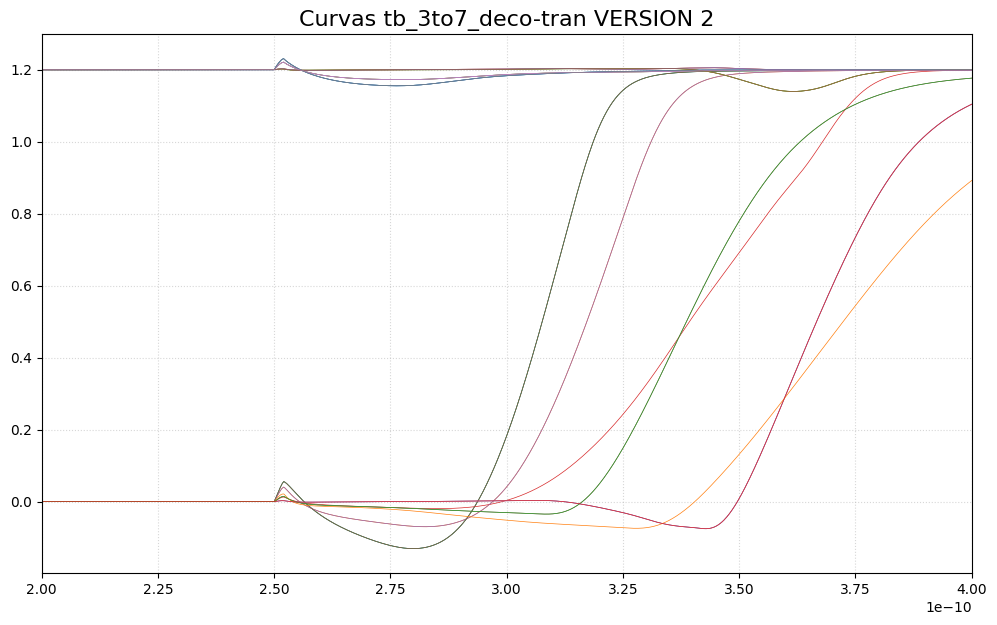

In [4]:
import matplotlib.pyplot as plt

todos_los_resultados = [resultados1V2, resultados2V2, resultados3V2, resultados4V2, resultados5V2, resultados6V2, resultados7V2]
# Nombres base que buscas
señales_buscadas = ['v(vo_st1)', 'v(vo_st2)', 'v(vo_st3)', 'v(vo_st4)', 'v(vo_st5)', 'v(vo_st6)', 'v(vo_st7)']

fig, ax = plt.subplots(figsize=[12, 7])

for i, res in enumerate(todos_los_resultados):
    # Obtenemos todas las llaves reales que hay en este archivo (ej: 'V(VO_ST1)')
    llaves_reales = res.keys()
    
    for s in señales_buscadas:
        # Buscamos si nuestra señal existe en las llaves reales (sin importar mayúsculas)
        encontrada = False
        for k in llaves_reales:
            if s.lower() == k.lower():
                ax.plot(res['time'], res[k], linewidth=0.5)
                encontrada = True
                break

# Configuraciones
ax.set_title('Curvas tb_3to7_deco-tran VERSION 2', fontsize=16)
ax.set_xlim([2e-10, 4e-10]) 
ax.grid(True, linestyle=':', alpha=0.5)
plt.show()